The papers studied have the intention to increase vorticity and with that have higher details in the simulation. 
The paper about vorticity refinement shows more details in some images and also adds an analisys claiming they increase the kinectic energy of the system with their approach, what would align with the fact that they add velocity to the system. They also want to show that their algorithm does not add energy indefinetely (like MP), it just adds in the moments where the fluid is moving more, what would be the moment where the most details are lost.

The vorticity confinement paper just shows increase in details but not in energy.

I spent much time trying to check if my implementation was correct by checking if indeed the energy increased or if the enstropgy in the system increases, but that's not the case for 3D VR implementation. And also not happens for VC implementation.

- What happens in inviscid liquids? Because in this case we wouldn't have an issue with the laplacian in theory
- Is this related to being small simulations? Would it make sense in a larger scenario, because the divergent part would be larger than the dissipation.
- Are we seeing a visual difference?

- Does this have to do with the fact that they are "ëxplict" integration? (should use the advected velocity?should compute derivative in the beginning of loop?) Should only correct the projection? 
- What happens to other advection projection schemes?
- What happens if i keep visc only on the vorticity part and not add visc to the simulation?
- Should we consider the forces term into account? (should change the derivative equation?)
- Is there something to do with SPH formulation? 


If it works:
- compare vorticity dissipated accross different methods (using the dissipation logic given by VR paper (eq - end))
- fluids of different viscosities - boundary interaction + Kelvin–Helmholtz Instability 
- analysis of viscosity X turbulent behavior
- scene where vorticity is more concentrated in a region?
- vortex bursting
- nazare

In [61]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt


In [62]:
splishsplash_path = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/'
scenes_path = splishsplash_path + 'data/Scenes/'
output_path = splishsplash_path + 'output'
scene = 'DamBreakModel'

In [63]:
folders = os.listdir(output_path + '/' + scene)
folders.remove('log')
print(folders)

['iisph_visc_standard_005', 'inviscid', 'visc_standard_005', 'vtk']


## Basic examples with VR, VC, MP with viscosity (paper only has viscosity)

#### Plots for kin energy and total energy
#### Plots for enstrophy
#### Plots for the VR equation (showing dissipation, and how the derivative decreases the vorticity)
#### video with all dam breaks side by side

In [148]:
folder_path = output_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
folders.remove('vtk_vr10_derneg_notgood')
folders.remove('vc_05_crossneg')
folders.remove('vr_10_crossneg')
folders.remove('vr_10_deltav_neg')
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/visc_standard_005/
['mp_01', 'mp_04', 'vc_01', 'vc_05', 'vr10_allcross_deri', 'vr10_deri', 'vr10_deri_pos', 'vr_10', 'vr_13', 'vr_baseline']


In [65]:
full_path = folder_path + folder + '/'
file = 'ParticleData_Fluid_50.vtk'
# print(file)
mesh = meshio.read(full_path + file)
print(mesh.point_data['mass'])
print(mesh.point_data['density'])

[1.0131031  1.0092624  1.0063419  ... 0.97186345 1.0046697  1.0049137 ]
[1000.65686 1000.95966 1000.6833  ...  968.909   1000.7622  1000.97107]


#### Energy

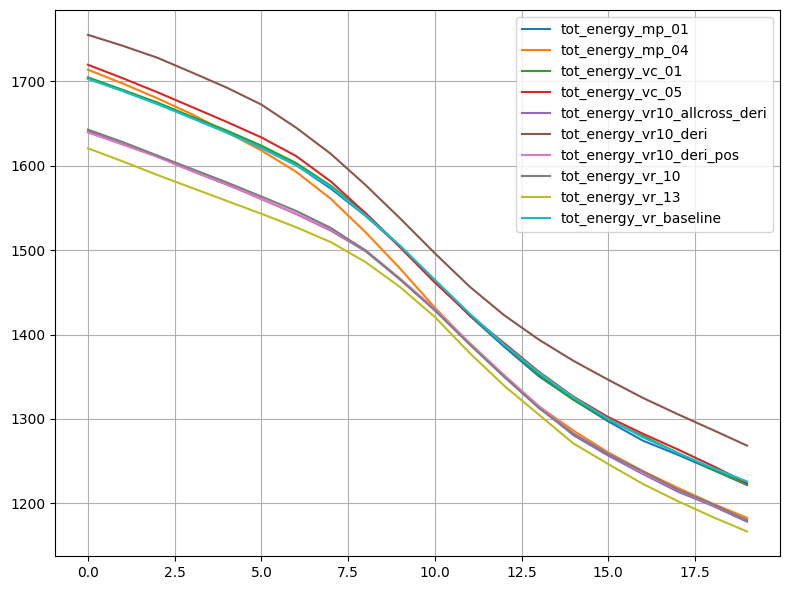

In [149]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(20,40):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

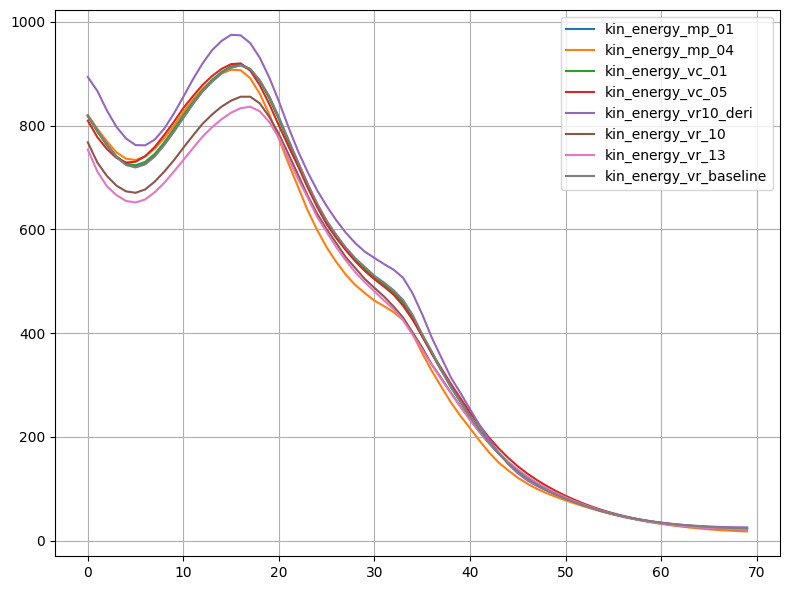

In [141]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

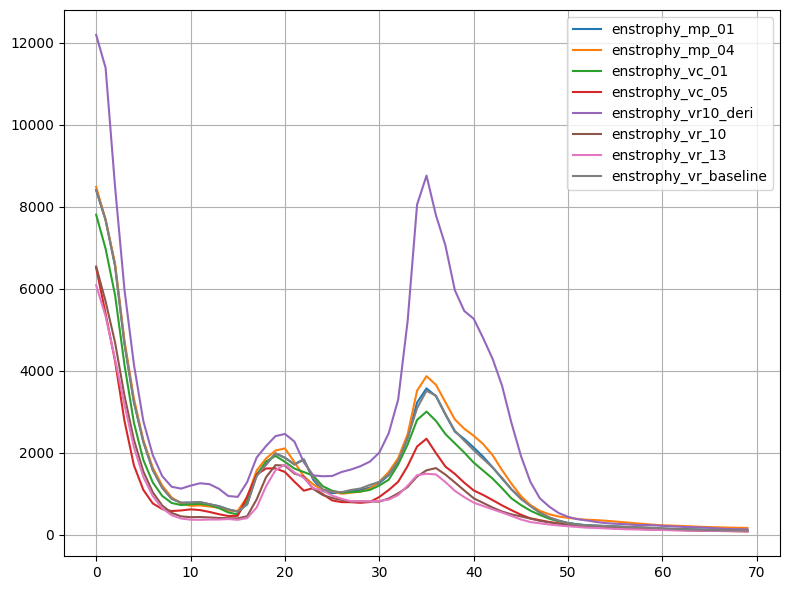

In [142]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR equation - vortcity dissipation

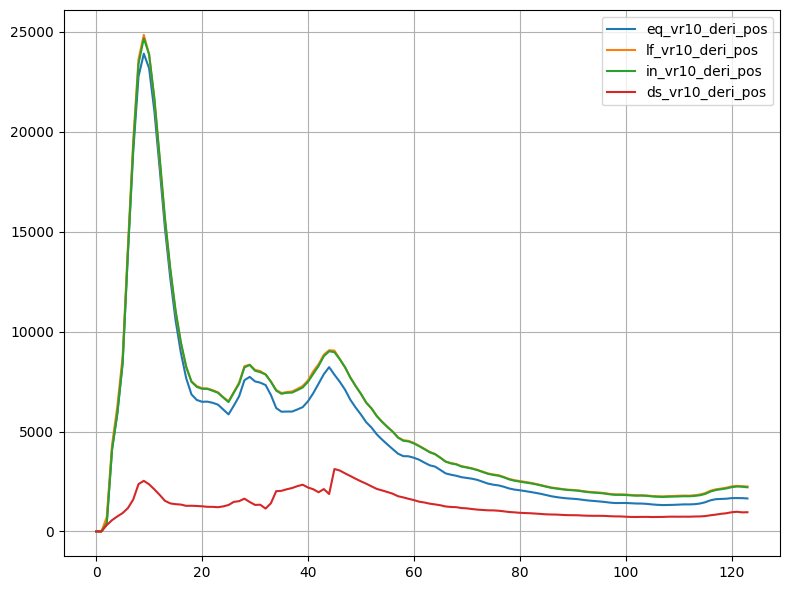

In [146]:
plt.figure(figsize=(8, 6))

# for folder in ['vr_10']:
for folder in ['vr10_deri_pos']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
    plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## What happens in inviscid fluids?

#### No viscosity to study the derivative
#### Plots for the derivative in VR
#### Plots for enstrophy
#### Plots for kin energy
#### Video

In [70]:
folder_path = output_path + '/' + scene + '/inviscid/'
# all visc in this folder is 0 and no xsph is applied
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/inviscid/
['mp_04', 'vc_05', 'vr_10', 'vr_13', 'vr_baseline']


#### Energy

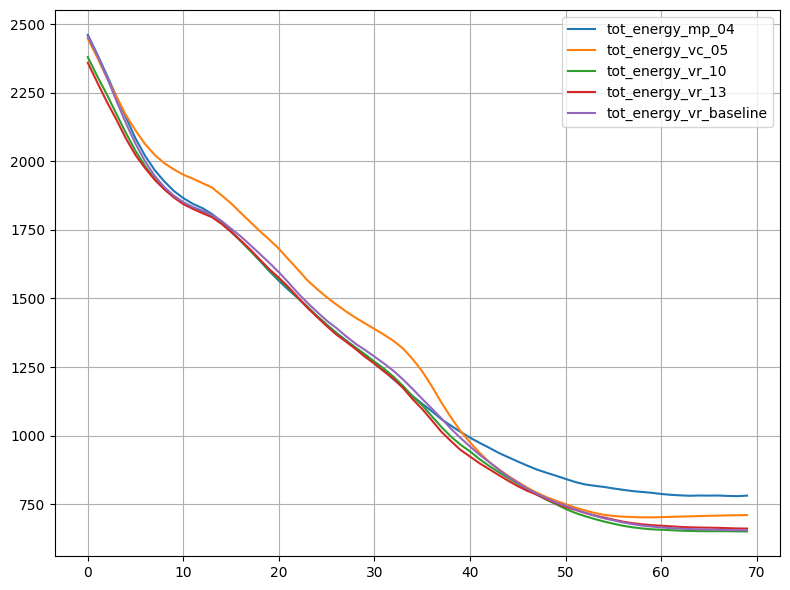

In [71]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

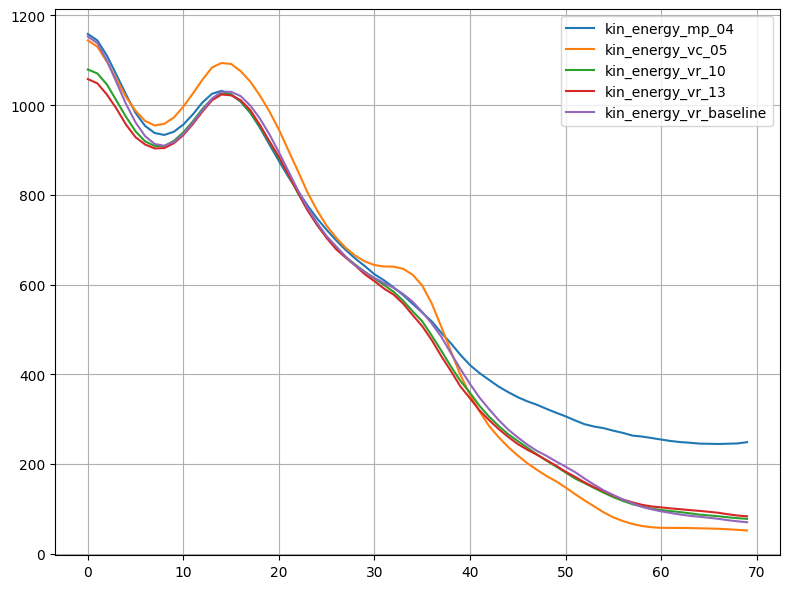

In [72]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

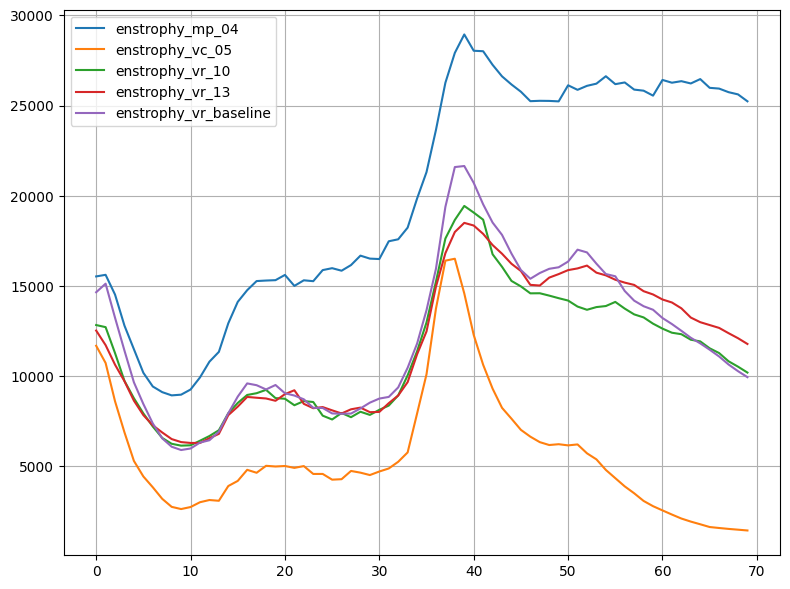

In [73]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR equation - vortcity dissipation

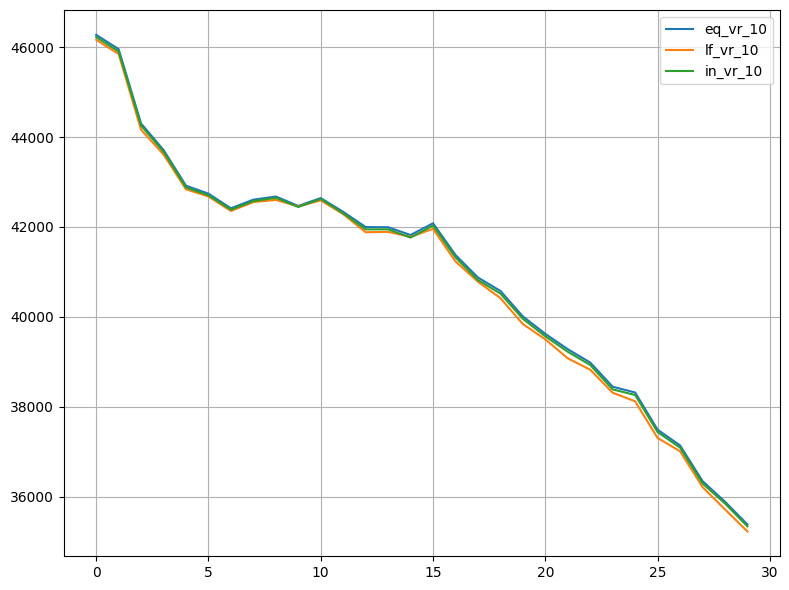

In [21]:
plt.figure(figsize=(8, 6))

for folder in ['vr_10']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(50,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## Some large simulations
Is the viscosity difusion more impactful in small scenes? Is there specific scenarios where energy increases or vorticity increases? Maybe only increases on part of the system
##### Since the difusion part of the derivative seems large, maybe large simulations with ingestion of vortex would have more energy

### Big dam break with wall (only gravity force, how does it react)
There are 2 scenarios simulated on the cluster, need to take csvs from there for plots here. Working on generating photos of the differences

In [14]:
thesis_path = 'C:/Users/gabri/Documents/thesis'
print(thesis_path)

files = os.listdir(thesis_path + '/dambreaklargewithwall/')
files.remove('baselinee')
files.remove('vr13')
files.remove('enstrophy_DamBreakModelLargeWithWall.csv')
files.remove('enstrophy_DamBreakModelLargeWithWallBaseline.csv')
files.remove('DamBreakModelLargeWithWall.json')
files.remove('DamBreakModelLargeWithWallBaseline.json')

print(files)

C:/Users/gabri/Documents/thesis
['kin_energy_DamBreakModelLargeWithWall.csv', 'kin_energy_DamBreakModelLargeWithWallBaseline.csv', 'pot_energy_DamBreakModelLargeWithWall.csv', 'pot_energy_DamBreakModelLargeWithWallBaseline.csv', 'total_energy_DamBreakModelLargeWithWall.csv', 'total_energy_DamBreakModelLargeWithWallBaseline.csv']


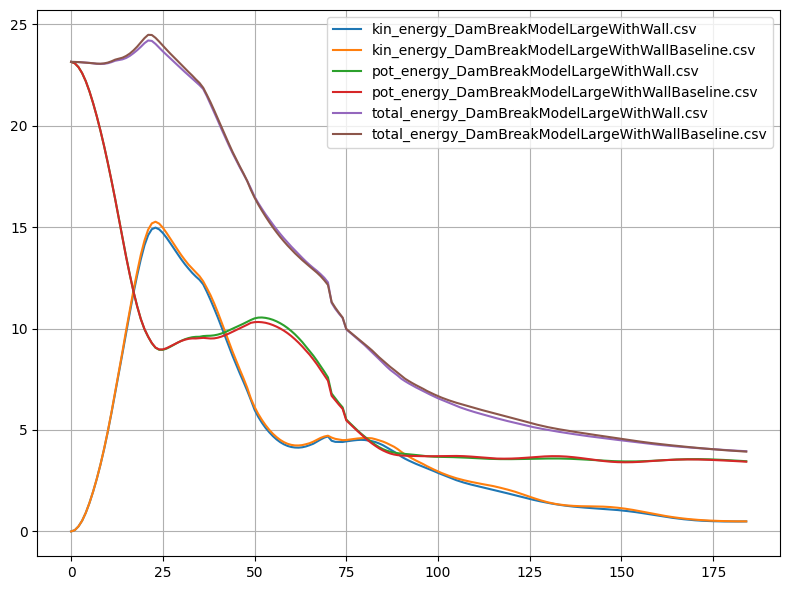

In [15]:
# Energy
plt.figure(figsize=(8, 6))
for file in files:
#     print(file)
    my_array = genfromtxt(thesis_path + '/dambreaklargewithwall/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

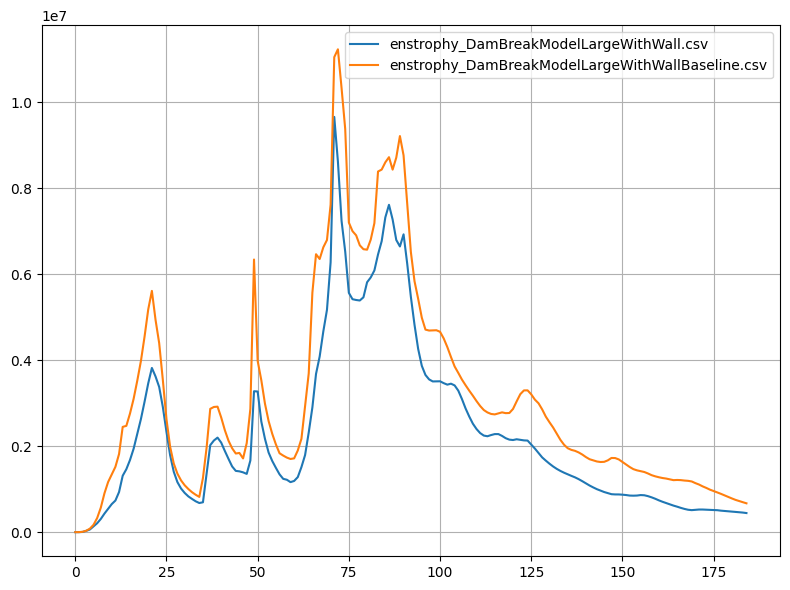

In [16]:
# Enstrophy
plt.figure(figsize=(8, 6))
for file in ['enstrophy_DamBreakModelLargeWithWall.csv', 'enstrophy_DamBreakModelLargeWithWallBaseline.csv']:
#     print(file)
    my_array = genfromtxt(thesis_path + '/dambreaklargewithwall/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Add comparisons here
#### Render front again for scene with more energy
#### Get exact moment of each scene

#### Scenes saved were 25,40,50,55,80,140,200

### Motor Large (energy being added to the system by motor, how does it react)

In [17]:
thesis_path = 'C:/Users/gabri/Documents/thesis'
print(thesis_path)

files = os.listdir(thesis_path + '/motorlarge/')
# files.remove('baselinee')
# files.remove('vr13')
files.remove('enstrophy_MotorSceneLarge.csv')
files.remove('enstrophy_MotorSceneLargeBaseline.csv')

print(files)

C:/Users/gabri/Documents/thesis
['kin_energy_MotorSceneLarge.csv', 'kin_energy_MotorSceneLargeBaseline.csv', 'pot_energy_MotorSceneLarge.csv', 'pot_energy_MotorSceneLargeBaseline.csv', 'total_energy_MotorSceneLarge.csv', 'total_energy_MotorSceneLargeBaseline.csv']


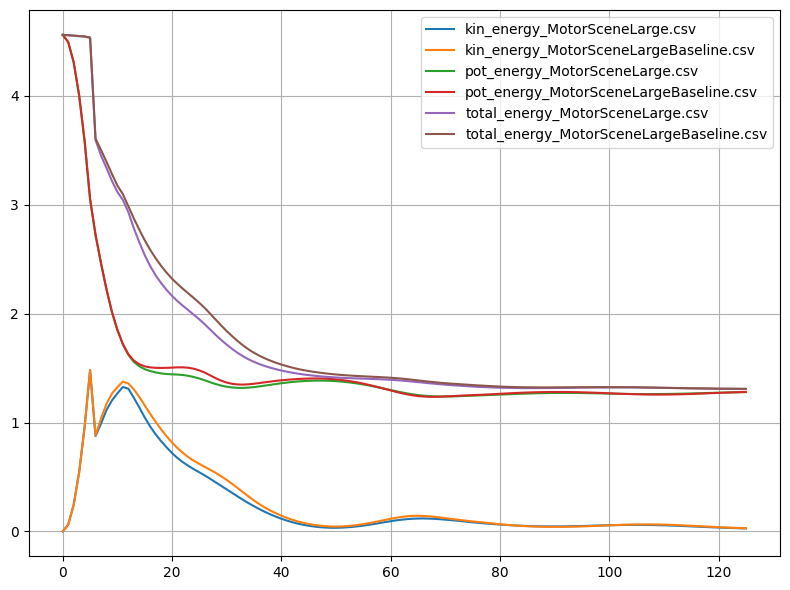

In [18]:
# Energy
plt.figure(figsize=(8, 6))
for file in files:
#     print(file)
    my_array = genfromtxt(thesis_path + '/motorlarge/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

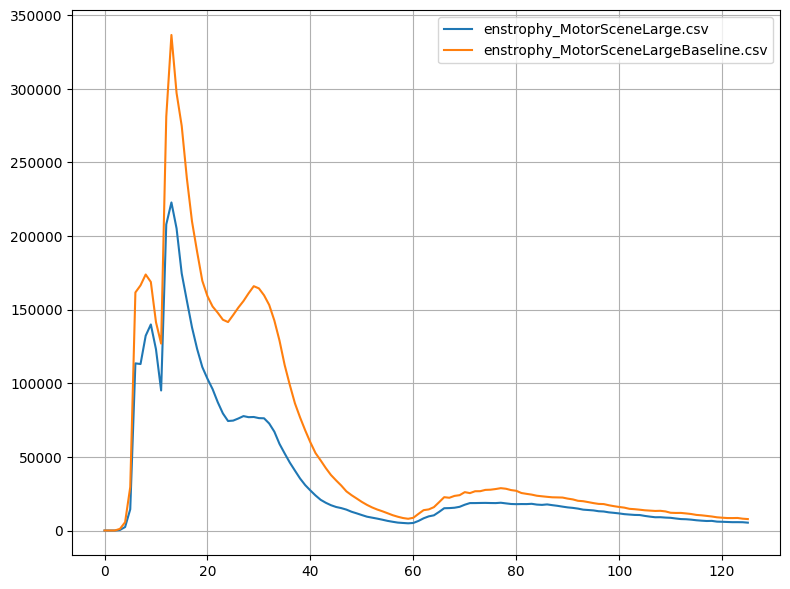

In [19]:
# Enstrophy
plt.figure(figsize=(8, 6))
for file in ['enstrophy_MotorSceneLarge.csv', 'enstrophy_MotorSceneLargeBaseline.csv']:
#     print(file)
    my_array = genfromtxt(thesis_path + '/motorlarge/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Get scenes from cluster (30,70)
#### Render scenes

### Rankine in 3d?

## Is there a change in looks?
https://www.youtube.com/watch?v=juCXCzmgcqE

###### Heatmap of velocity vorticity accross different scenarios could show if some method gives more impact in specific parts of the simulation (on a part where energy is added for example)

## Does this have to do with the fact that they are "ëxplict" integration? (should use the advected velocity?should compute derivative in the beginning of loop?)

#### 1. Derivative in beginning of loop, using velocity after DFSPH and position after DFSPH

### VISCOSITY

In [95]:
folder_path = output_path + '/' + scene + '/dfsph_visc_standard_005_derivative_beginning/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/dfsph_visc_standard_005_derivative_beginning/
['baseline', 'vr13']


#### Energy

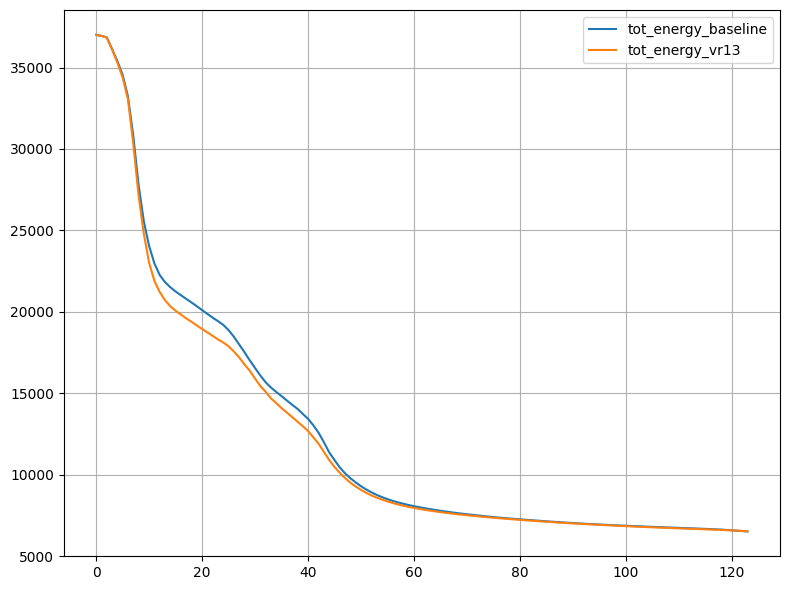

In [96]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

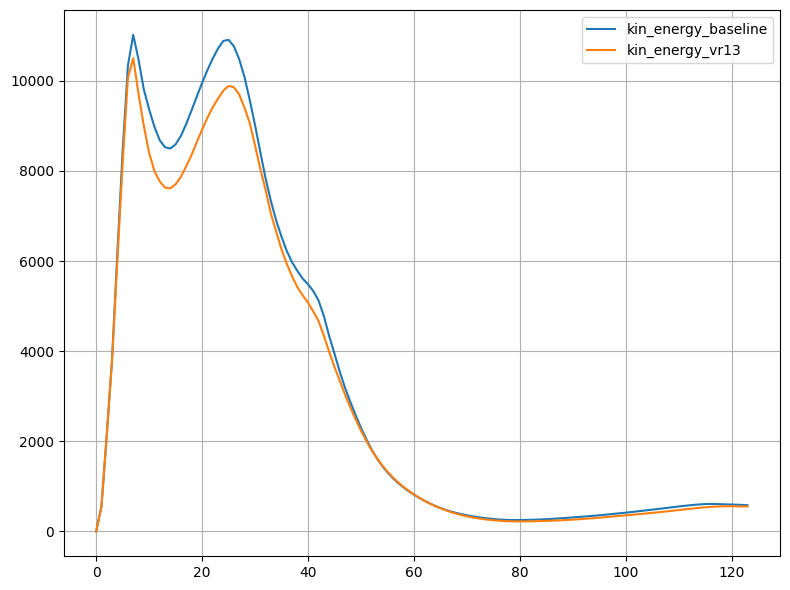

In [97]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

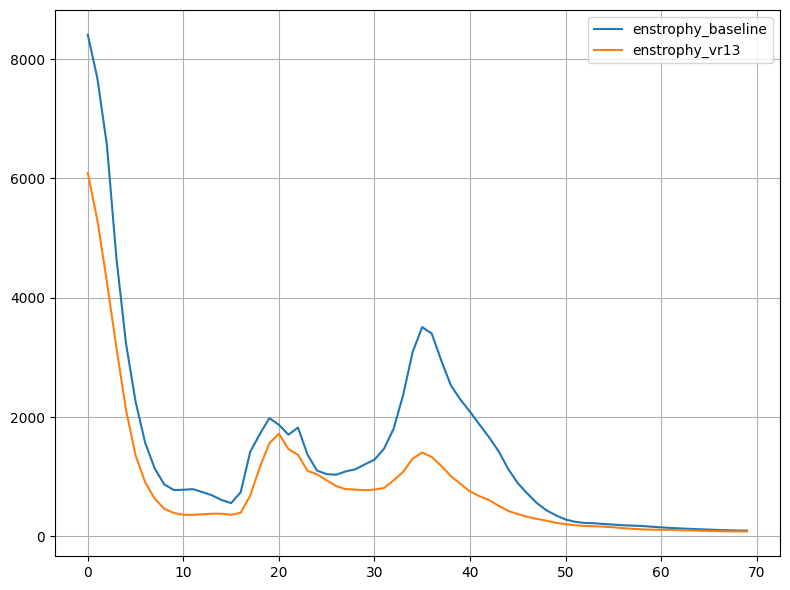

In [98]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR Equation

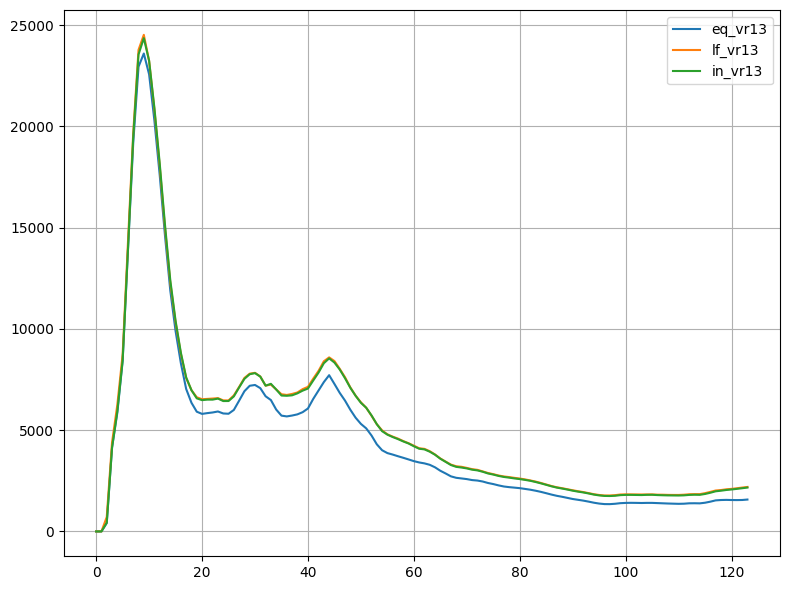

In [101]:
plt.figure(figsize=(8, 6))

for folder in ['vr13']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### INVISCID

In [120]:
folder_path = output_path + '/' + scene + '/dfsph_inviscid_derivative_beginning/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/dfsph_inviscid_derivative_beginning/
['baseline', 'vr10']


#### Energy

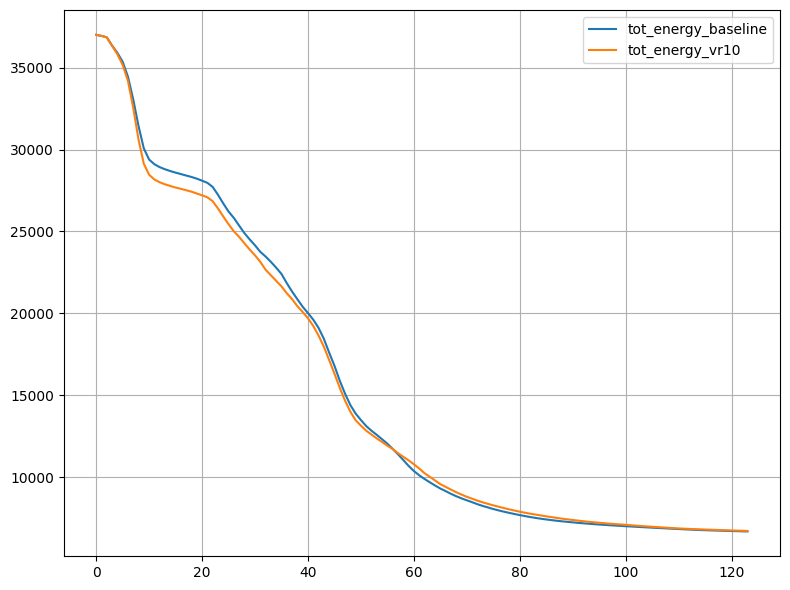

In [121]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

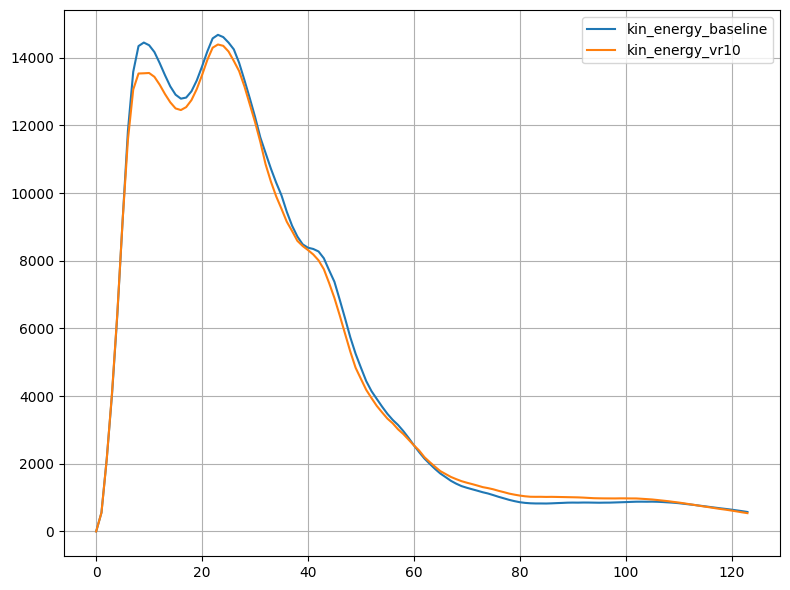

In [122]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

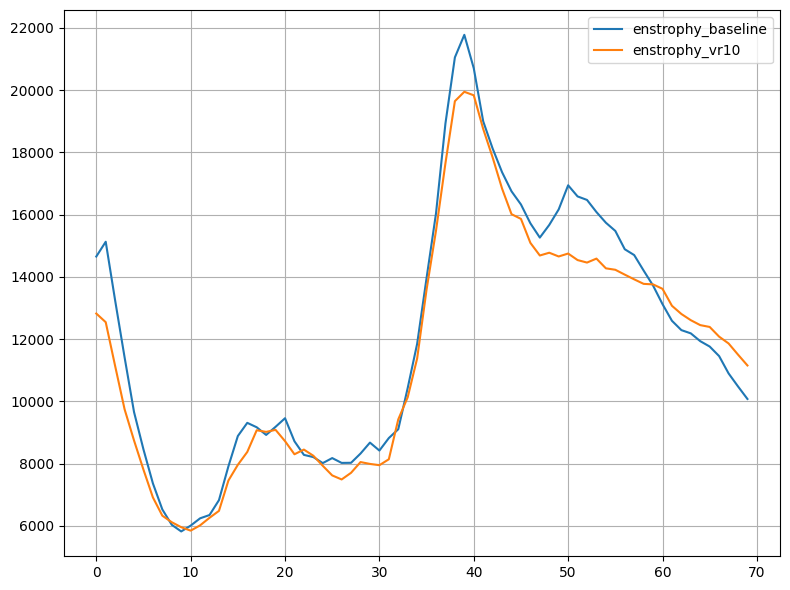

In [124]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR Equation

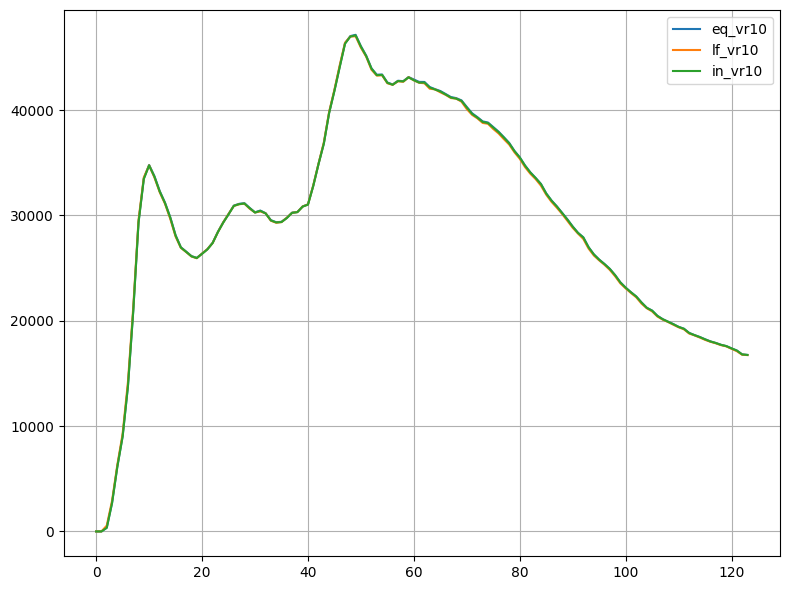

In [126]:
plt.figure(figsize=(8, 6))

for folder in ['vr10']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### 2. Use advected velocity to compute derivative (without the divergene free part)
##### In this case move the vorticity to be last step of non pressure forces, to get acceleration and compute advected velocity
##### derivative in beginning of time step and using acceleration from previous round. Then it saves current acceleration on vector for next step

### VISCOSITY

In [107]:

folder_path = output_path + '/' + scene + '/dfsph_visc_standard_005_advected_velocity_for_derivative/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/dfsph_visc_standard_005_advected_velocity_for_derivative/
['baseline', 'vr10']


#### Energy

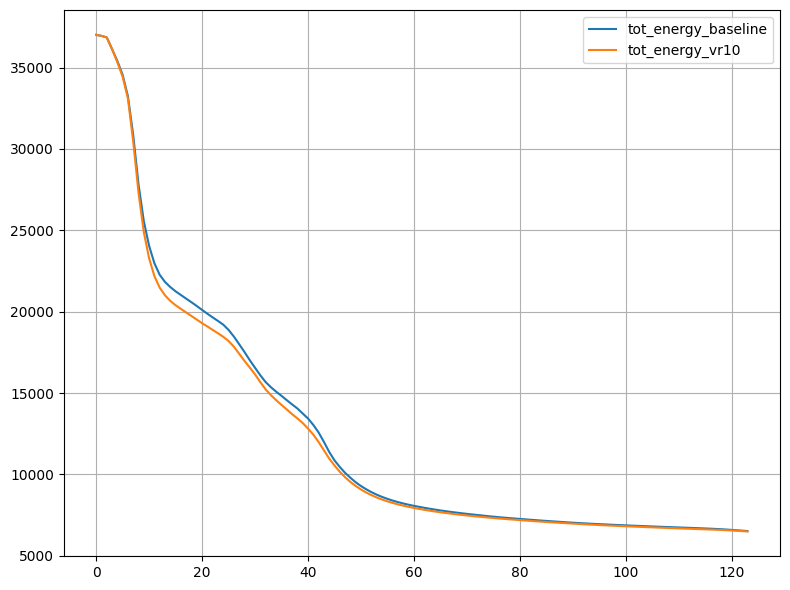

In [108]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

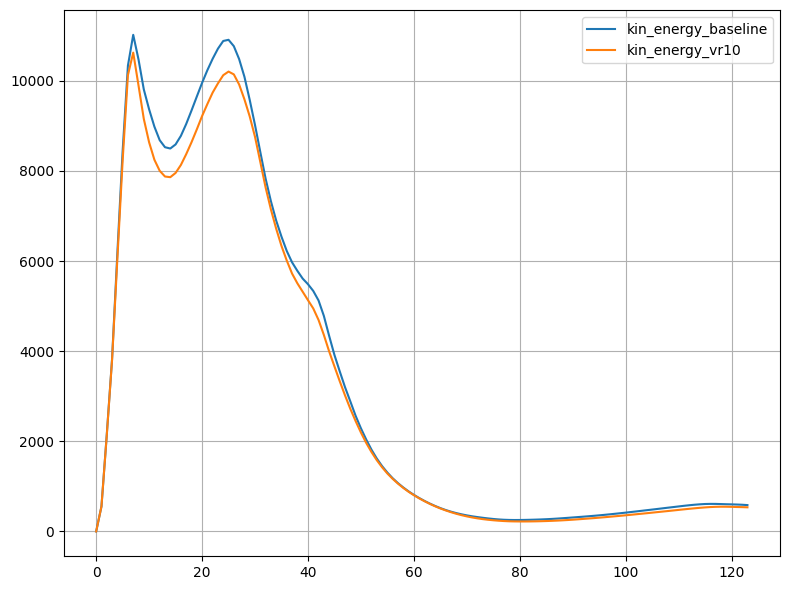

In [109]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

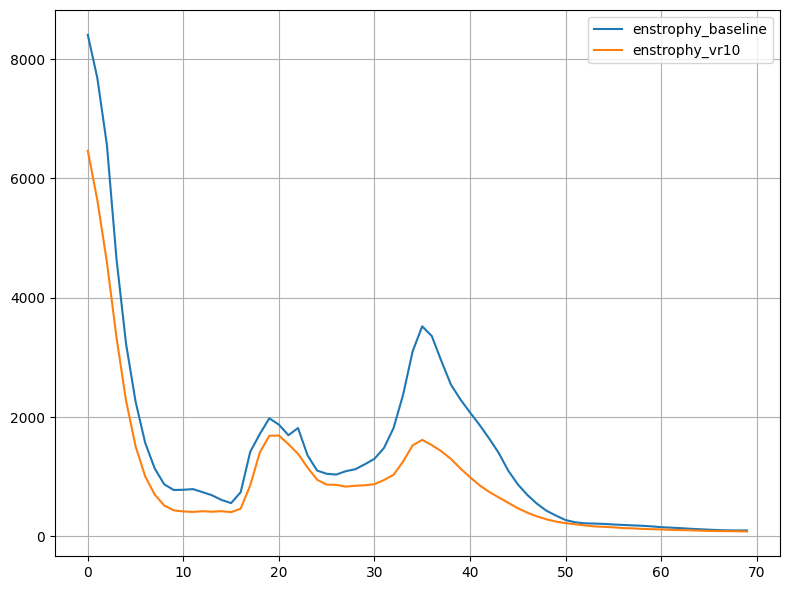

In [110]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### INVISCID

In [112]:
folder_path = output_path + '/' + scene + '/dfsph_inviscid_advected_velocity_for_derivative/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/dfsph_inviscid_advected_velocity_for_derivative/
['baseline', 'vr10']


#### Energy

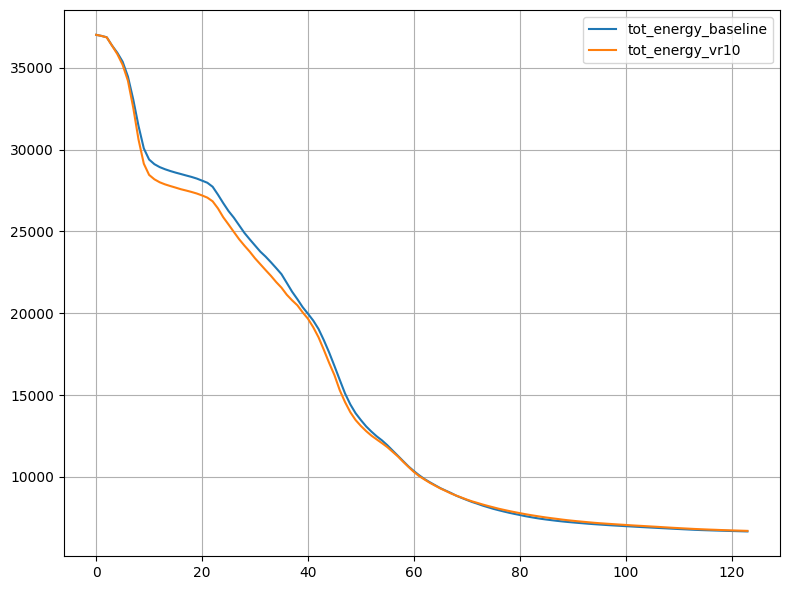

In [113]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

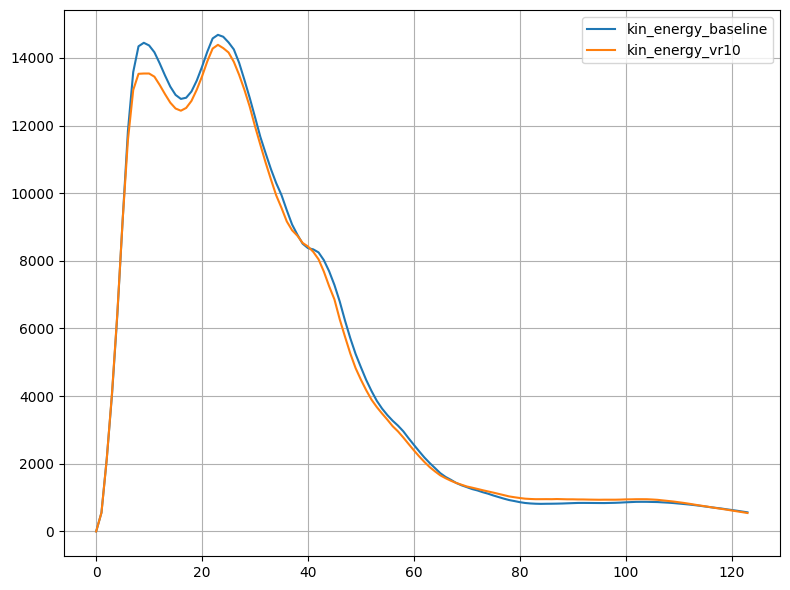

In [114]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

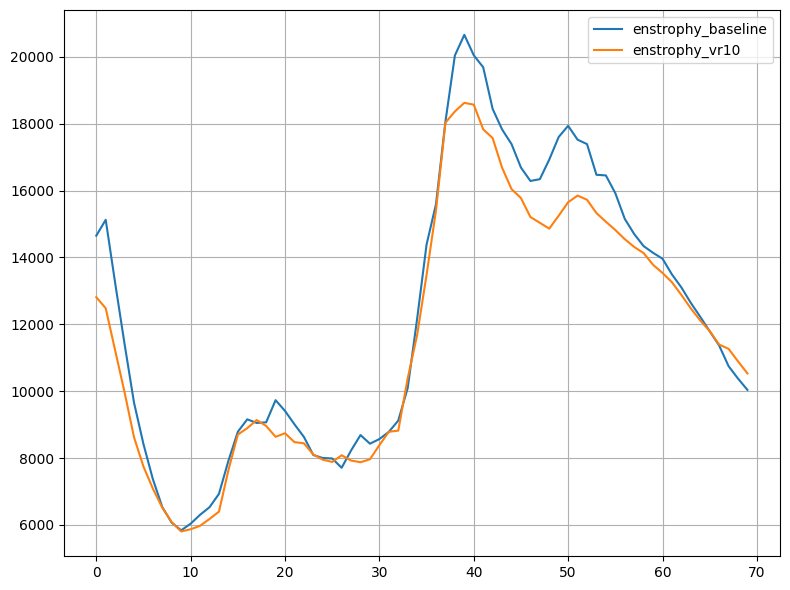

In [115]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR Equation

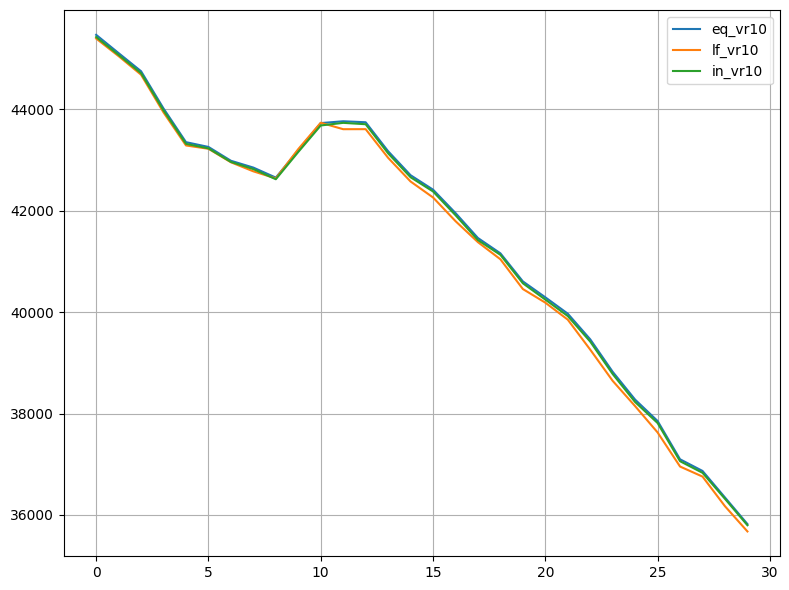

In [118]:
plt.figure(figsize=(8, 6))

for folder in ['vr10']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(50,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### 3. Correct only the projection part? -> not stable

In [150]:
### Vorticity in the end
### derivative in the beginning of loop
### derivative uses advected velocity
### new "vorticity_corrected_end" which uses advected velocty

## What happens with other advection-projection schemes
#### IISPH
#### PCISPH
#### Does it work in a non advection-projection scheme?

### IISPH

In [80]:
# iisph_visc_standard_005

folder_path = output_path + '/' + scene + '/iisph_visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/iisph_visc_standard_005/
['baseline', 'vr_13']


In [81]:
full_path = folder_path + 'baseline' + '/'
file = 'ParticleData_Fluid_5.vtk'
# print(full_path + file)
mesh = meshio.read(full_path + file)
print(mesh.point_data['mass'])
print(mesh.point_data['m_masses'])
print(mesh.point_data['density'])
print(mesh.point_data['density']  * 0.8 * 0.05 * 0.05 * 0.05)

[-146.44301 -191.54439 -198.49846 ... -491.1157  -331.927   -331.92703]
[-146.44301 -191.54439 -198.49846 ... -491.1157  -331.927   -331.92703]
[ 999.5041 1086.4065 1091.8885 ...  575.7289  680.23    680.2299]
[0.09995041 0.10864066 0.10918887 ... 0.05757289 0.06802301 0.068023  ]


#### Energy

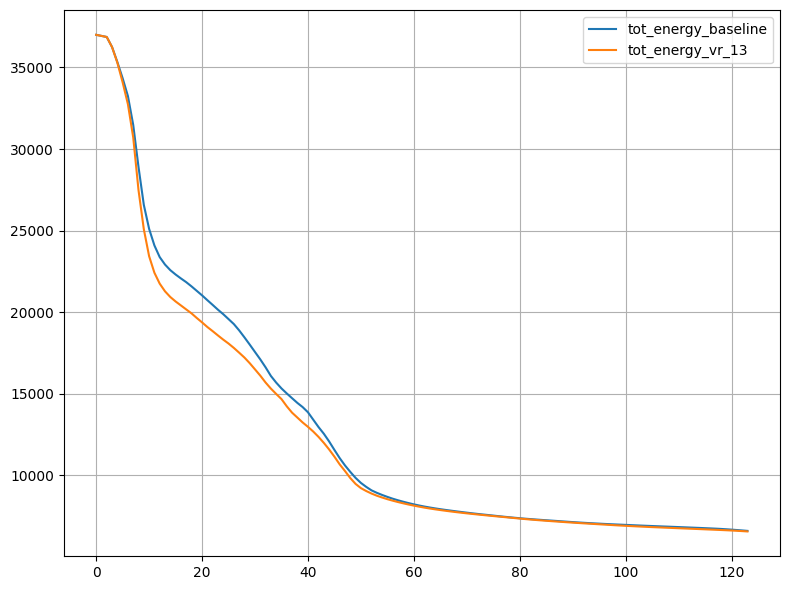

In [83]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

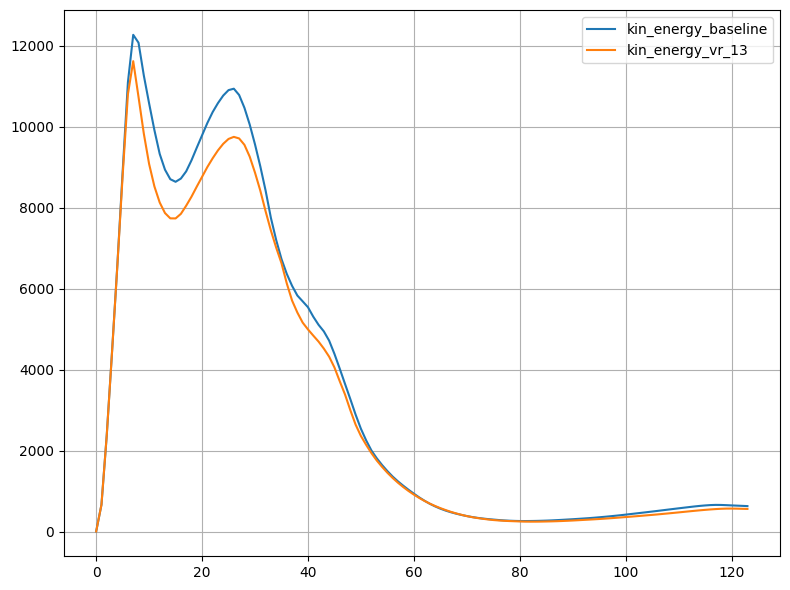

In [84]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

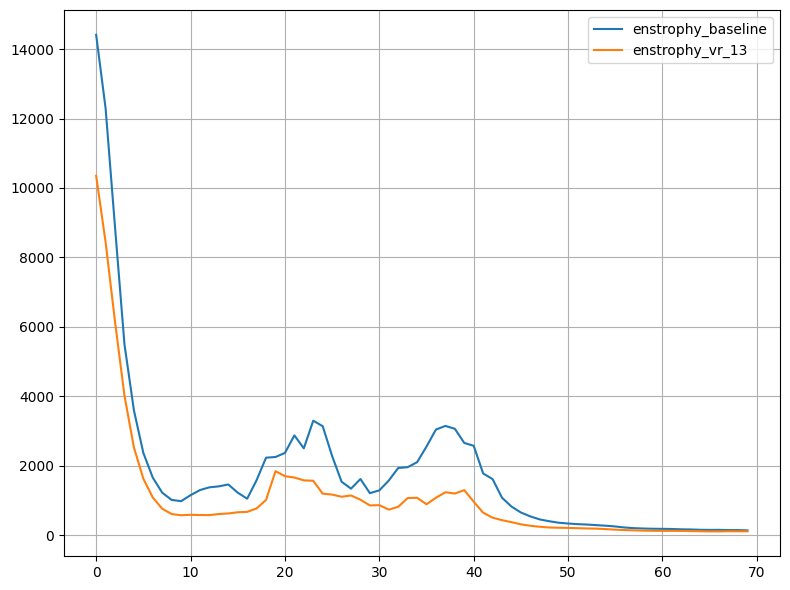

In [85]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### PCISPH

In [90]:
# iisph_visc_standard_005

folder_path = output_path + '/' + scene + '/pcisph_visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/pcisph_visc_standard_005/
['baseline', 'vr13']


#### Energy

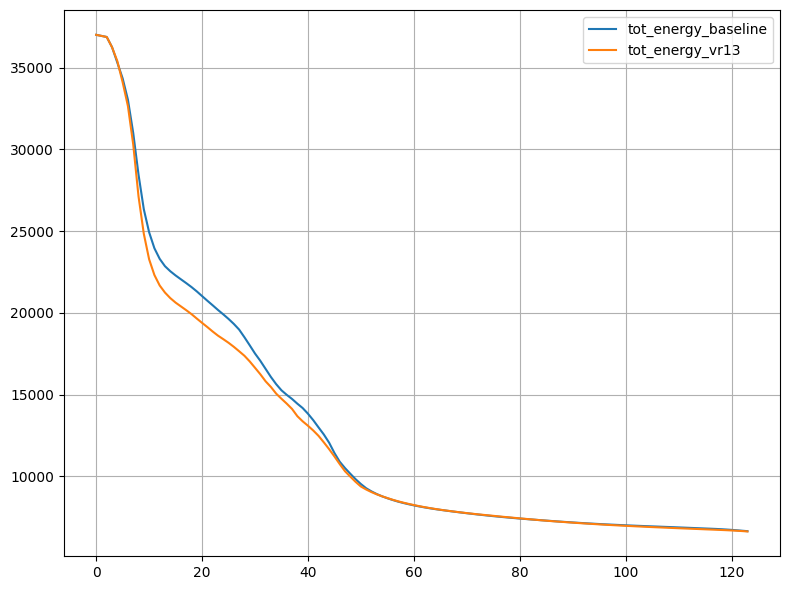

In [91]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

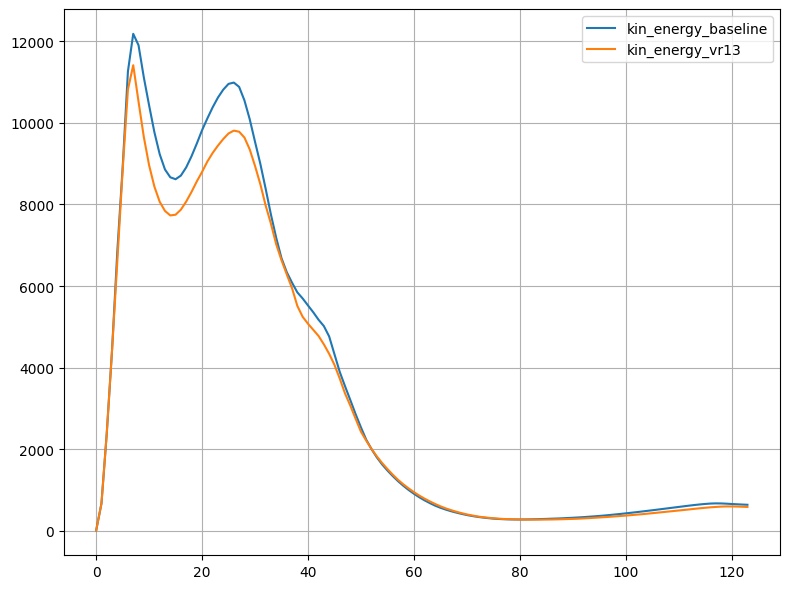

In [92]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

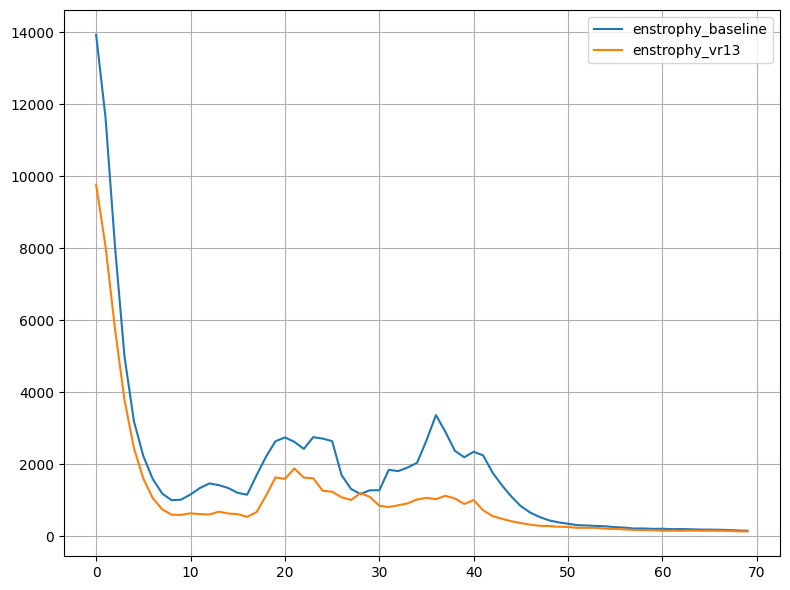

In [93]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## What happens if i keep visc only on the vorticity part and not add visc to the simulation? -> not stable

## Should we consider the forces term into account? (should change the derivative equation to include the forces term?)

In [158]:
folder_path = output_path + '/' + scene + '/dfsph_visc_forces/'
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/dfsph_visc_forces/
['baseline', 'vr10', 'vr10_deltavneg']


#### Energy

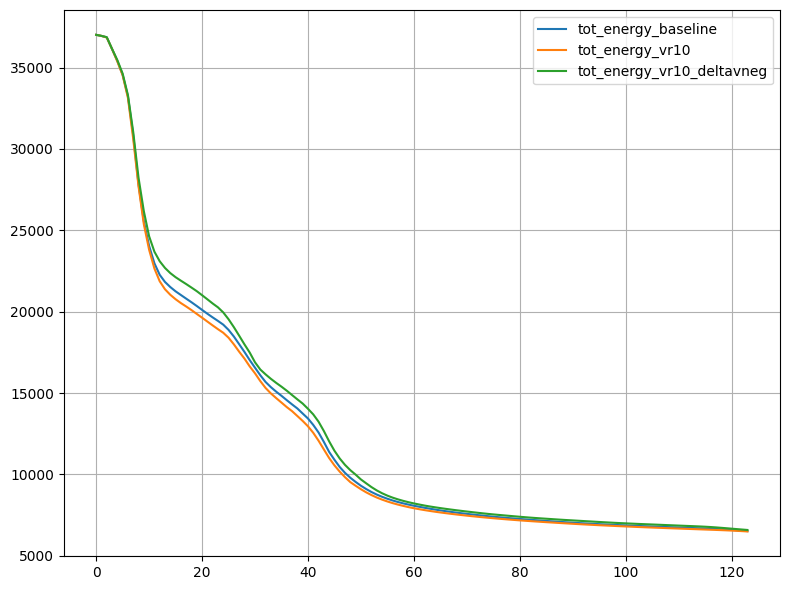

In [159]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

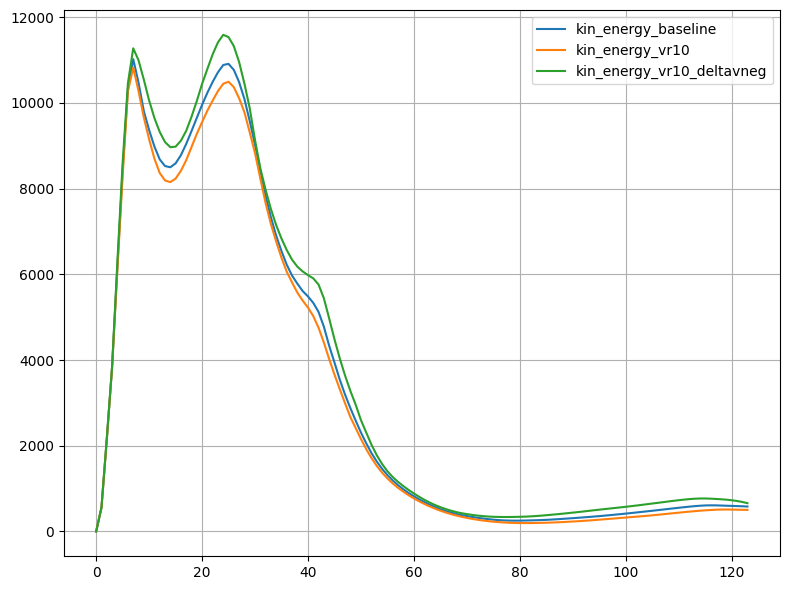

In [160]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

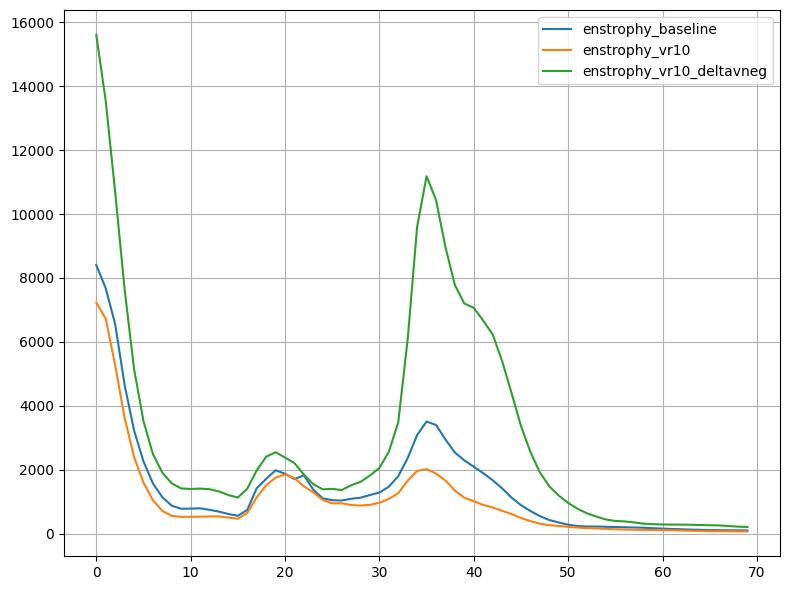

In [161]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## Spinning cube

In [183]:
folder_path = output_path + '/2cubescoliding/'
print(folder_path)

folders = os.listdir(folder_path)
folders.remove('log')
# folders.remove('mp01')
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/2cubescoliding/
['baseline', 'mp01', 'vr10', 'vr10_deltaneg']


#### Energy

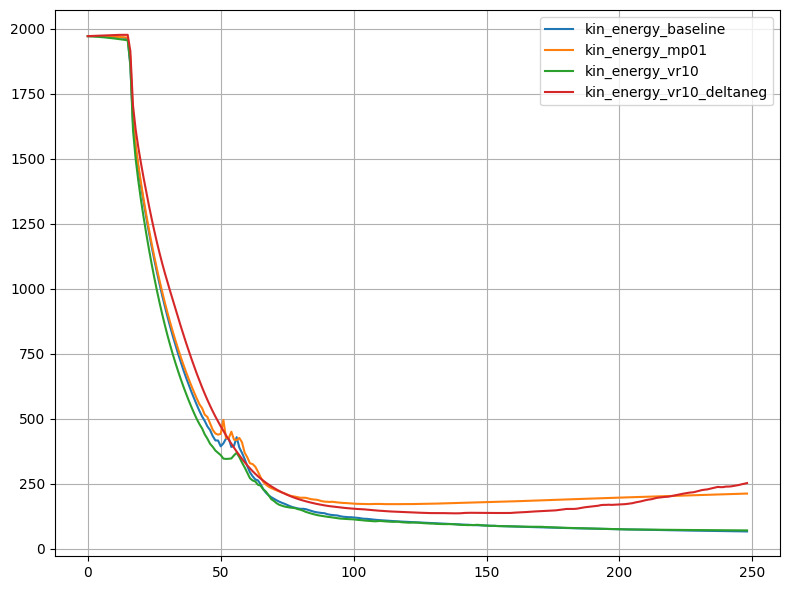

In [185]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(1,250):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

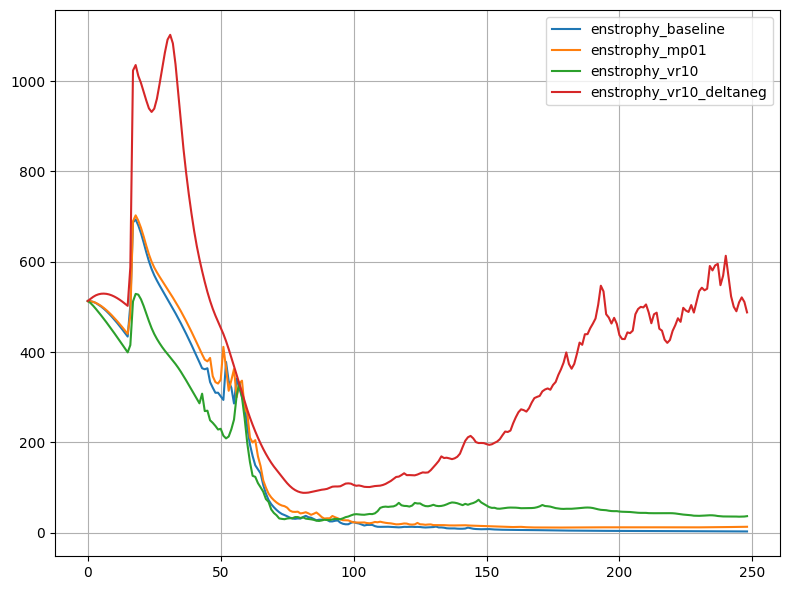

In [186]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(1,250):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['density'] * 0.8 * 0.05 * 0.05 * 0.05

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## Is there something to do with SPH formulation?